In [7]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2035_free_2000.nc'
)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [9]:
n.generators.loc[['BA0 0 0 solar'], ['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt', 'p_nom_extendable']]

,p_nom,p_nom_min,p_nom_max,p_nom_opt,p_nom_extendable
Generator,,,,,
BA0 0 0 solar,267.1,267.1,87204.366509,267.100033,True


In [17]:
path = Path.cwd().parent / 'results' / 'duals'
template = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT+fast_{}_{}_mu.csv'
fns = list(path.glob('*.csv'))

In [18]:
def weighted_average(quantity: pd.Series, weights: pd.Series) -> float:
    """
    Compute the weighted average of `quantity` using `weights`.

    Both inputs must be pandas Series with the same index.
    NaNs are dropped pairwise. Returns NaN if no valid data or sum of weights is 0.
    """
    if not isinstance(quantity, pd.Series) or not isinstance(weights, pd.Series):
        raise TypeError("quantity and weights must both be pandas Series.")

    if not quantity.index.equals(weights.index):
        raise ValueError("quantity and weights must have the same index (same labels and order).")

    df = pd.concat({"q": quantity, "w": weights}, axis=1).dropna()
    if df.empty:
        return float("nan")

    wsum = df["w"].sum()
    if wsum == 0:
        return float("nan")

    return (df["q"] * df["w"]).sum() / wsum

In [19]:
usage = 2000
col = pd.read_csv(
    path / template.format(usage, 'upper'), index_col=1
).iloc[:, 1].rename(usage).mul(1e-3)
col.sort_values().head(50)

name
FR5 0 home battery charger                                         -1378.954350
RS0 0 home battery charger                                         -1144.608586
SK0 0 home battery charger                                         -1135.750104
HR0 0 home battery charger                                         -1135.445205
BA0 0 home battery charger                                         -1129.422530
PL0 0 home battery charger                                         -1114.669673
ME0 0 home battery charger                                         -1089.539807
RS0 0 battery charger                                              -1069.401067
SI0 0 battery charger                                              -1055.907959
BA0 0 battery charger                                              -1054.662975
PL0 0 battery charger                                              -1040.331916
ME0 0 battery charger                                              -1016.019729
MK0 0 home battery charger         

In [22]:
from tqdm import tqdm

uppers_fast = list()
lowers_fast = list()
uppers_medium = list()
lowers_medium = list()

carriers = [
    'offwind',
    'onwind',
    'solar',
    'industrial heat pump high temperature',
    'industrial heat pump medium temperature',
    'air heat pump',
    'ground heat pump',
    'CCGT',
    'OCGT',
    'biomass boiler',
]

# wiggles = list(range(0, 4000, 250))
wiggles = [2000]

# Process 'fast' scenario
for wiggle in tqdm(wiggles):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_{}_{}.nc'.format('NT+fast', wiggle)
    )

    uppers_df = pd.read_csv(
            path / template.format('free', wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    
    # print(uppers_df.index.isin(n.generators.index.union(n.links.index)).all())

    index = list()
    weighted_avg = list()
    avg = list()

    for carrier in carriers:

        ss = uppers_df.loc[uppers_df.index.str.contains(carrier)]

        if ss.empty:
            continue

        gens = ss.index[ss.index.str.contains(carrier)].intersection(n.generators.index)
        links = ss.index[ss.index.str.contains(carrier)].intersection(n.links.index)

        caps = n.generators.loc[gens, 'p_nom_opt'] if links.empty else n.links.loc[links, 'p_nom_opt']

        wgt_avg = weighted_average(ss, caps)

        # print(carrier)
        # print(wgt_avg)
        # print(ss.mean())

        index.append(carrier)
        weighted_avg.append(wgt_avg)
        avg.append(ss.mean())
    
    uppers_fast.append(
        pd.DataFrame(
            {'weighted_avg': weighted_avg, 'avg': avg},
            index=index
        )
    )

# Process 'medium' scenario
for wiggle in tqdm(wiggles):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+{}_{}.nc'.format('medium', wiggle)
    )

    uppers_df = pd.read_csv(
            path / template.format('medium', wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    
    # print(uppers_df.index.isin(n.generators.index.union(n.links.index)).all())

    index = list()
    weighted_avg = list()
    avg = list()

    for carrier in carriers:

        ss = uppers_df.loc[uppers_df.index.str.contains(carrier)]

        if ss.empty:
            continue

        gens = ss.index[ss.index.str.contains(carrier)].intersection(n.generators.index)
        links = ss.index[ss.index.str.contains(carrier)].intersection(n.links.index)

        caps = n.generators.loc[gens, 'p_nom_opt'] if links.empty else n.links.loc[links, 'p_nom_opt']

        wgt_avg = weighted_average(ss, caps)

        # print(carrier)
        # print(wgt_avg)
        # print(ss.mean())

        index.append(carrier)
        weighted_avg.append(wgt_avg)
        avg.append(ss.mean())
    
    uppers_medium.append(
        pd.DataFrame(
            {'weighted_avg': weighted_avg, 'avg': avg},
            index=index
        )
    )

  0%|          | 0/1 [00:00<?, ?it/s]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
  0%|          | 0/1 [00:01<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/home/lukas/Desktop/res/v1/pypsa-eur/results/duals/base_s_50__3H-T-H-B-I-A-dist1_2035_NT+fast_free_2000_mu.csv'

In [193]:
fast = pd.concat(uppers_fast, axis=1, keys=wiggles).mul(1e-3)
medium = pd.concat(uppers_medium, axis=1, keys=wiggles).mul(1e-3)
fast.drop('solar', axis=0, inplace=True)
medium.drop('solar', axis=0, inplace=True)
fast = fast.mul(-1)
medium = medium.mul(-1)

In [194]:
fast.T.dropna().T

1000                     1250  \
                                        weighted_avg         avg weighted_avg   
offwind                                    71.110136   83.892625    43.517470   
onwind                                     37.205357   48.362389    20.537329   
industrial heat pump high temperature     175.811452  146.151042   100.352692   
industrial heat pump medium temperature   159.537848  134.639295    97.279887   
air heat pump                             304.931366  169.990667   181.110031   
ground heat pump                          384.329361  387.102403   241.852584   

                                                            2250             \
                                                avg weighted_avg        avg   
offwind                                   45.073590    19.034329  15.691308   
onwind                                    25.167667     7.746891   7.385527   
industrial heat pump high temperature     76.816456    10.842826   9.648640   
industrial heat pump medium temperature   73.774195    10.228737   9.099135   
air heat pump                             87.349512    58.910046   8.163417   
ground heat pump                         210.875620    74.118069  24.901859   

                                                2750                   3250  \
                                        weighted_avg       avg weighted_avg   
offwind                                     7.165432  4.132675     2.356110   
onwind                                      2.212440  1.232998     0.351043   
industrial heat pump high temperature       2.658685  2.553476     0.782990   
industrial heat pump medium temperature     2.117545  2.077151     0.686195   
air heat pump                              28.066271  0.229485    -0.000000   
ground heat pump                           57.231036  0.814484    -0.000000   

                                                          3750            \
                                              avg weighted_avg       avg   
offwind                                  0.895628     0.616945  0.259631   
onwind                                   0.252412    -0.000000 -0.000000   
industrial heat pump high temperature    0.838370     0.152578  0.131416   
industrial heat pump medium temperature  0.585922     0.170873  0.087533   
air heat pump                           -0.000000    -0.000000 -0.000000   
ground heat pump                        -0.000000    -0.000000 -0.000000   

                                                4000            
                                        weighted_avg       avg  
offwind                                     0.360273  0.190584  
onwind                                     -0.000000 -0.000000  
industrial heat pump high temperature       0.062567  0.088064  
industrial heat pump medium temperature     0.258181  0.069893  
air heat pump                              -0.000000 -0.000000  
ground heat pump                           -0.000000 -0.000000

In [213]:
carrier_mapper = {
    'air heat pump': 'urban decentral air heat pump',
    'ground heat pump': 'rural ground heat pump',
    'industrial heat pump high temperature': 'heat100-200 industry industrial heat pump high temperature',
    'industrial heat pump medium temperature': 'heat<100 industry industrial heat pump medium temperature',
    'offwind': 'offwind-ac',
    'onwind': 'onwind',
}

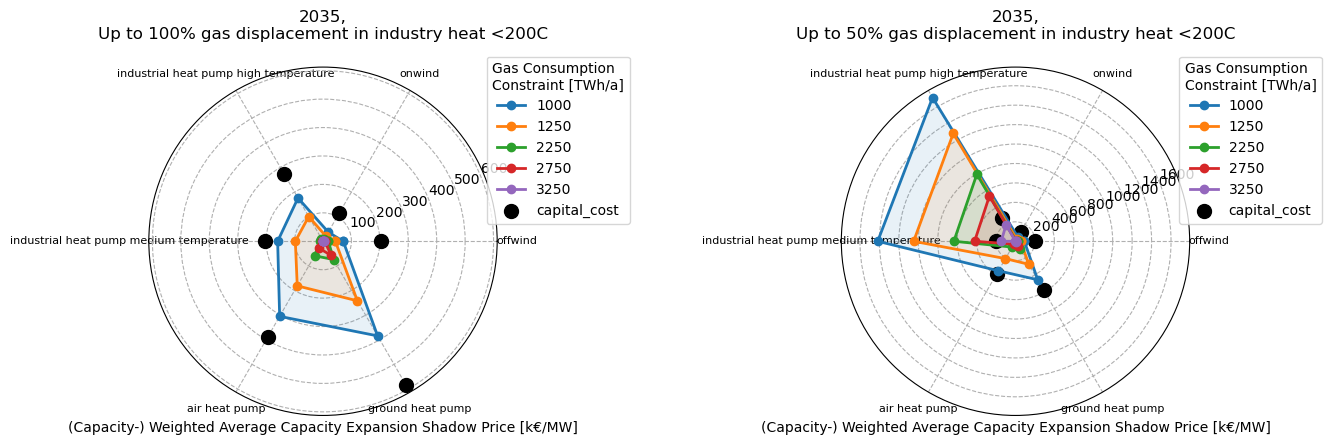

In [217]:
# Create polar plot with one axis for each carrier
fig = plt.figure(figsize=(14, 7))

num_carriers = len(fast.index)
angles = np.linspace(0, 2 * np.pi, num_carriers, endpoint=False).tolist()

# Select subset of columns to plot
# columns_to_plot = ['weighted_avg']
data = [fast, medium]

for (col_idx, df), title in zip(
    enumerate(data),
    [
        '2035,\nUp to 100% gas displacement in industry heat <200C',
        '2035,\nUp to 50% gas displacement in industry heat <200C'
    ]
):
    ax = fig.add_subplot(1, len(data), col_idx + 1, projection='polar')
    
    for wiggle in [1000, 1250, 2250, 2750, 3250]:
        values = []
        for carrier in df.index:
            try:
                val = df.loc[carrier, (wiggle, 'weighted_avg')]
                values.append(val)
            except:
                values.append(0)
        
        # Close the plot by appending first value
        values += values[:1]
        angles_plot = angles + angles[:1]
        
        ax.plot(angles_plot, values, 'o-', linewidth=2, label=f'{wiggle}')
        ax.fill(angles_plot, values, alpha=0.1)
    
    ax.set_xticks(angles)
    ax.set_xticklabels(df.index, size=8)
    ax.set_title(title, size=12, pad=20)
    
    # Add capital cost marker to legend
    ax.scatter([], [], color='k', s=100, label='capital_cost')

    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.05), title='Gas Consumption\nConstraint [TWh/a]')
    ax.grid(True, ls='--')
    ax.set_axisbelow(True)

    ax.set_xlabel('(Capacity-) Weighted Average Capacity Expansion Shadow Price [k€/MW]')

    for carrier, angle in zip(df.index, angles):

        if carrier not in ['onwind', 'offwind', 'solar']:
            capcost = n.links.loc[n.links.carrier == carrier_mapper[carrier], 'capital_cost'].mean() * 1e-3
        else:
            capcost = n.generators.loc[n.generators.carrier == carrier_mapper[carrier], 'capital_cost'].mean() * 1e-3

        ax.scatter([angle], [capcost], color='k', s=100)


plt.tight_layout()
plt.show()

In [208]:
n.links.loc[n.links.carrier.str.contains('industrial heat pump high temperature'), ['capital_cost', 'carrier']].head().iloc[0,-1]

'heat100-200 industry industrial heat pump high temperature'

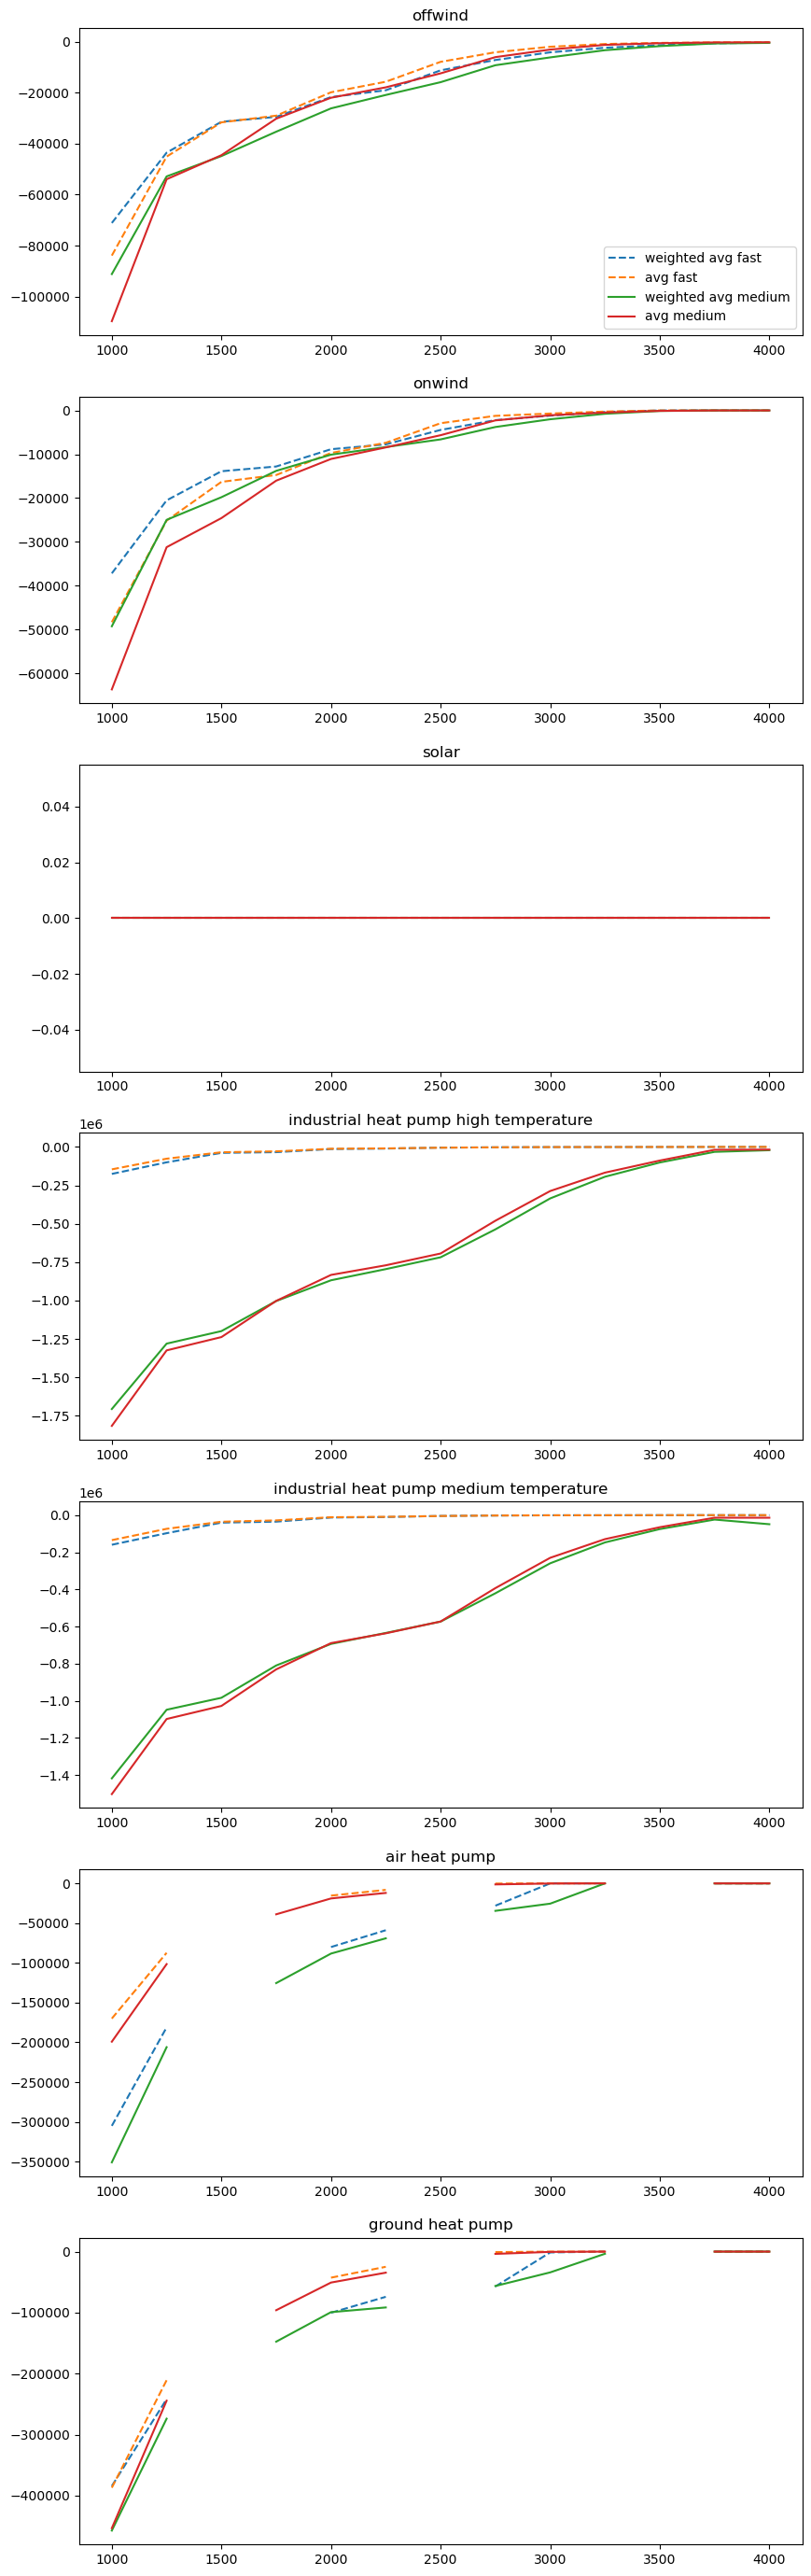

In [20]:
idx = pd.IndexSlice

fig, axs = plt.subplots(len(uppers.index), 1, figsize=(10, len(uppers.index) * 5))


for i, (carrier, ax) in enumerate(zip(uppers.index, axs)):
    
    ss = uppers.loc[carrier].unstack()

    ax.plot(ss.index, ss.loc[:, 'weighted_avg'], label='weighted avg fast', ls='--')
    ax.plot(ss.index, ss.loc[:, 'avg'], label='avg fast', ls='--')

    ss = medium.loc[carrier].unstack()

    ax.plot(ss.index, ss.loc[:, 'weighted_avg'], label='weighted avg medium', ls='-')
    ax.plot(ss.index, ss.loc[:, 'avg'], label='avg medium', ls='-')

    ax.set_title(carrier)

    if not i:
        ax.legend()

plt.show()

In [115]:
n.generators.loc[n.generators.index.str.contains('offwind')].capital_cost

Generator
AL0 0 0 offwind-float    295775.684948
BA0 0 0 offwind-float    289260.940080
BE0 0 0 offwind-float    293290.029022
BG0 0 0 offwind-float    297816.980591
DE0 0 0 offwind-float    295544.785594
                             ...      
NL0 0 0 offwind-dc       237284.163108
NO1 0 0 offwind-dc       236800.860740
PL0 0 0 offwind-dc       223961.928240
RO0 0 0 offwind-dc       222124.145120
SE1 0 0 offwind-dc       227113.643892
Name: capital_cost, Length: 101, dtype: float64

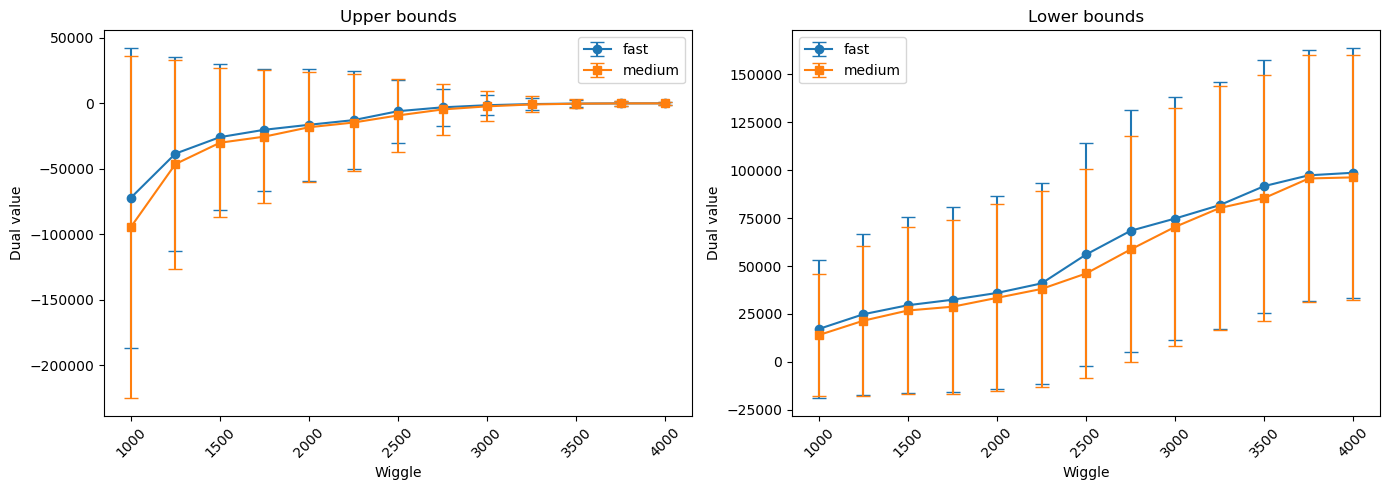

In [94]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

carrier = 'wind'

# Prepare data for upper bounds
ss_fast = uppers_fast.loc[uppers_fast.index.str.contains(carrier)]
ss_medium = uppers_medium.loc[uppers_medium.index.str.contains(carrier)]

# Calculate mean and std for upper bounds
mean_fast_upper = ss_fast.mean()
std_fast_upper = ss_fast.std()
mean_medium_upper = ss_medium.mean()
std_medium_upper = ss_medium.std()

# Plot upper bounds
axs[0].errorbar(mean_fast_upper.index, mean_fast_upper.values, yerr=std_fast_upper.values, 
                label='fast', marker='o', capsize=5)
axs[0].errorbar(mean_medium_upper.index, mean_medium_upper.values, yerr=std_medium_upper.values, 
                label='medium', marker='s', capsize=5)
axs[0].set_title('Upper bounds')
axs[0].set_xlabel('Wiggle')
axs[0].set_ylabel('Dual value')
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()

# Prepare data for lower bounds
ss_fast_lower = lowers_fast.loc[lowers_fast.index.str.contains(carrier)]
ss_medium_lower = lowers_medium.loc[lowers_medium.index.str.contains(carrier)]

# Calculate mean and std for lower bounds
mean_fast_lower = ss_fast_lower.mean()
std_fast_lower = ss_fast_lower.std()
mean_medium_lower = ss_medium_lower.mean()
std_medium_lower = ss_medium_lower.std()

# Plot lower bounds
axs[1].errorbar(mean_fast_lower.index, mean_fast_lower.values, yerr=std_fast_lower.values, 
                label='fast', marker='o', capsize=5)
axs[1].errorbar(mean_medium_lower.index, mean_medium_lower.values, yerr=std_medium_lower.values, 
                label='medium', marker='s', capsize=5)
axs[1].set_title('Lower bounds')
axs[1].set_xlabel('Wiggle')
axs[1].set_ylabel('Dual value')
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend()

plt.tight_layout()
plt.show()

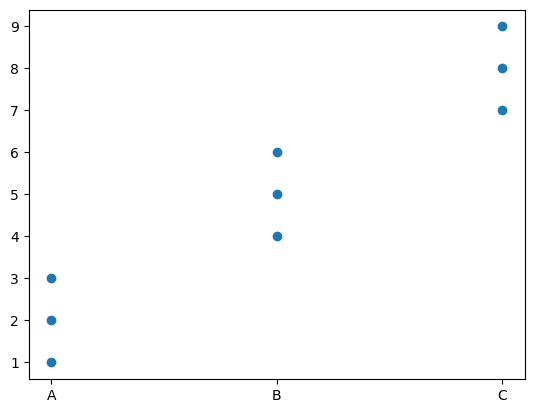

In [70]:
plt.scatter(x, y)

In [20]:
from tqdm import tqdm
import geopandas as gpd

regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [25]:
template = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT+fast_{}_{}_mu.csv'

In [41]:
ud.sample(50)

name
NO1 0 home battery charger                                         -472410.952062
HR0 0 0 solar                                                           -0.000000
SE1 0 0 offwind-ac                                                      -0.000000
FR0 4 0 solar                                                           -0.000000
AT0 0 0 onwind                                                      -12798.677808
GB2 0 0 solar                                                           -0.000000
CH0 0 battery charger                                              -877209.286850
NL0 0 0 offwind-dc                                                  -32651.363169
BG0 0 0 solar                                                           -0.000000
DE0 2 0 solar                                                           -0.000000
CZ0 0 0 onwind                                                      -82350.185636
DK1 0 battery charger                                                   -0.000000
DE0 0 0 sol

In [ ]:
ud = pd.read_csv(
        path / template.format(wiggle, 'upper'), index_col=1
    ).iloc[:, 1].rename(wiggle)
    
ud[ud.index.str.contains(' heat pump')]

Series([], Name: 2000, dtype: float64)

In [44]:
from itertools import product

uppers = list()

carriers = [
    'offwind',
    'onwind',
    'solar',
    'industrial heat pump high temperature',
    'industrial heat pump medium temperature',
    'battery charger',
    'home battery charger',
    'rural ground heat pump',
    'decentral air heat pump',
    'central air heat pump',
    'CCGT',
    'OCGT',
    'biomass boiler',
]

# wiggles = list(range(1000, 4250, 250))
wiggles = [2000]

for scen, wiggle in product(['fast'], wiggles):

    uppers_df = pd.read_csv(
            path / template.format(wiggle, 'upper'), index_col=1
        ).iloc[:, 1].rename(wiggle)
    
    for carrier in carriers:

        ss = uppers_df.loc[uppers_df.index.str.contains(carrier)]

        if ss.empty:
            continue

        ss = ss.groupby(ss.index.str[:5]).mean().reindex(regions.index).rename((scen, carrier, wiggle)).mul(1e-3)

        uppers.append(ss)


In [45]:
df = pd.concat(uppers, axis=1)

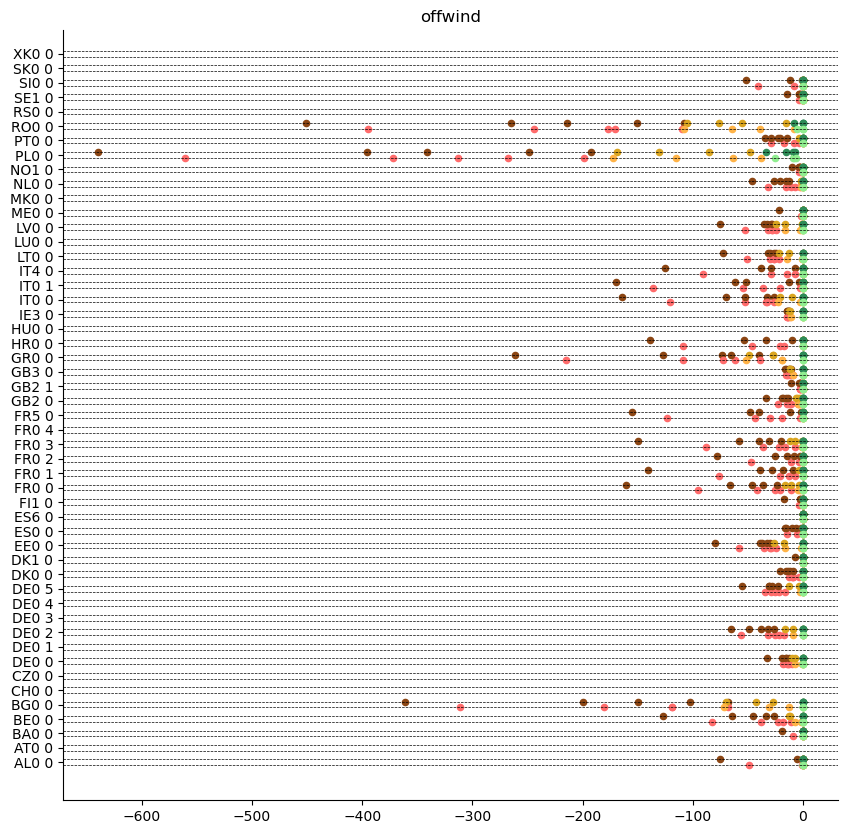

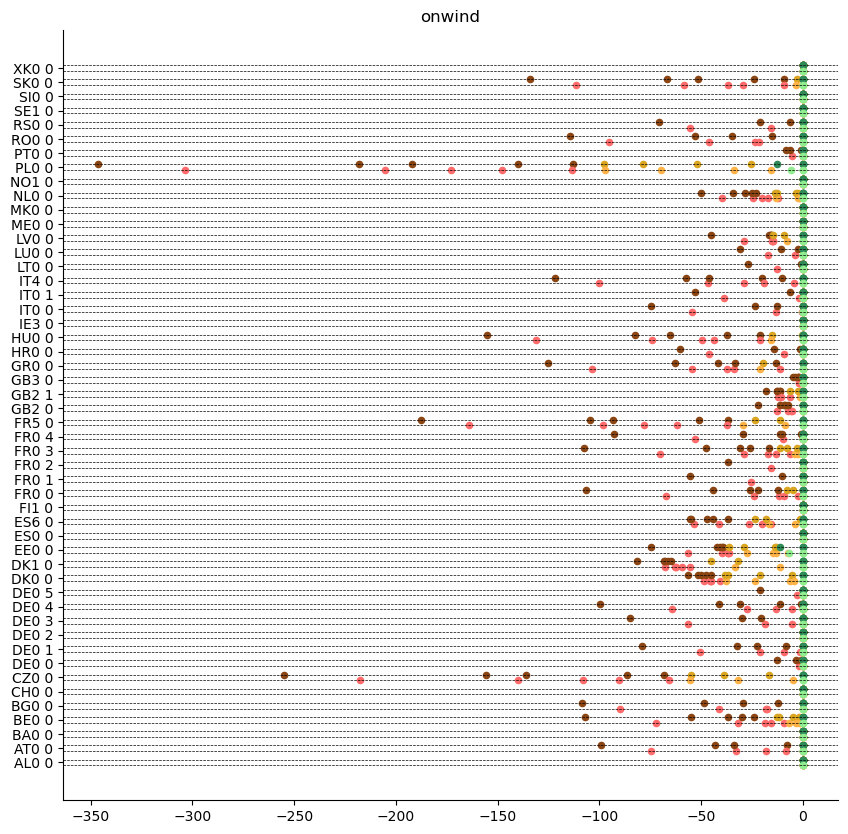

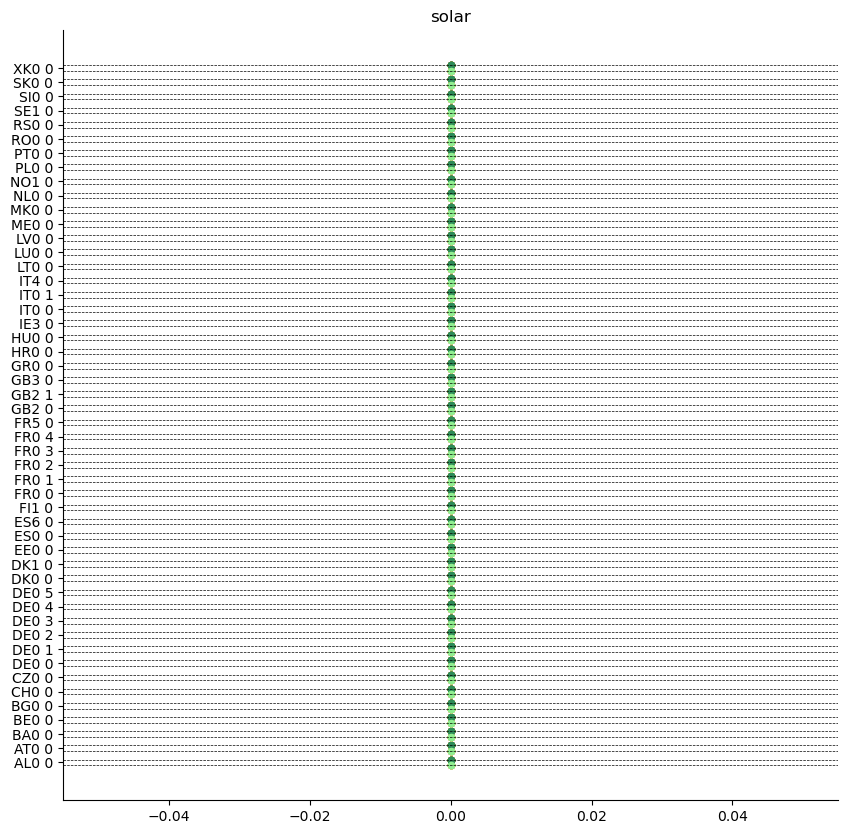

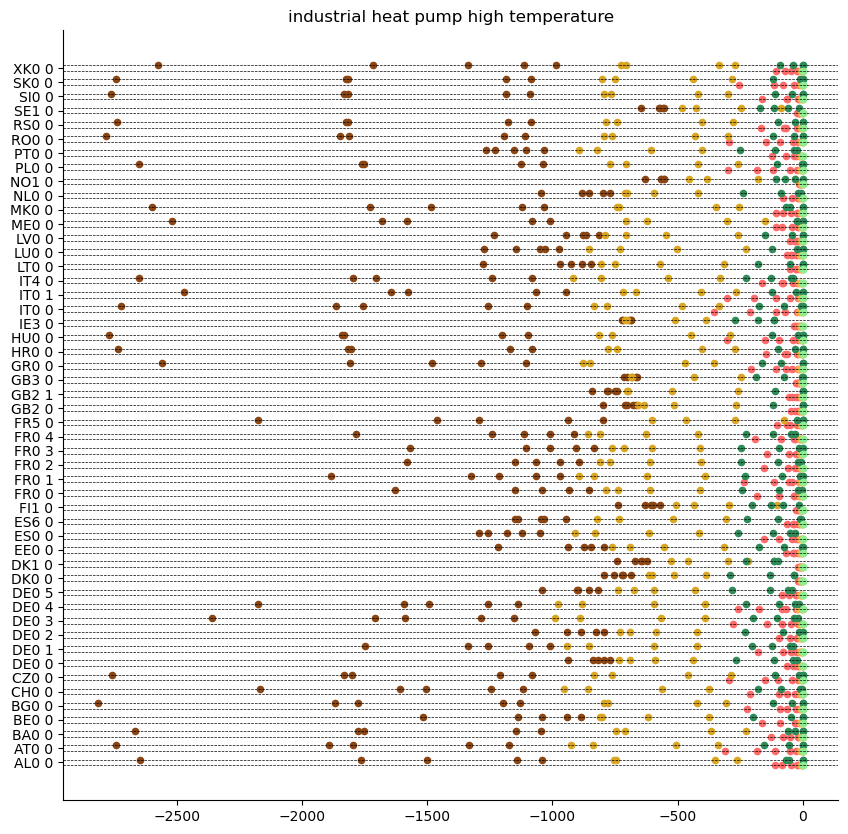

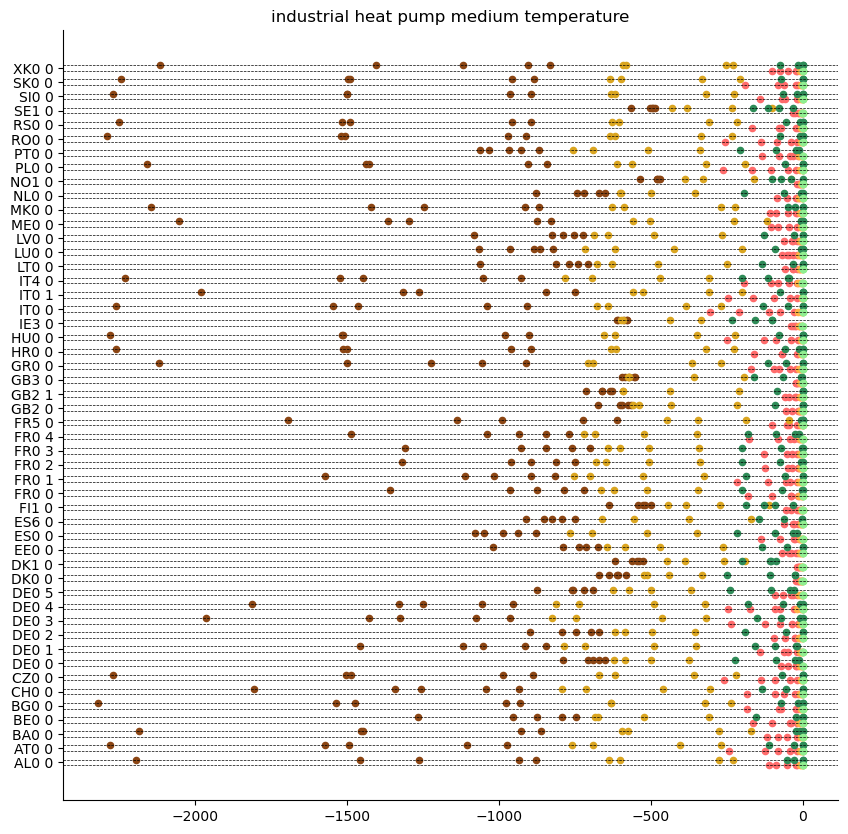

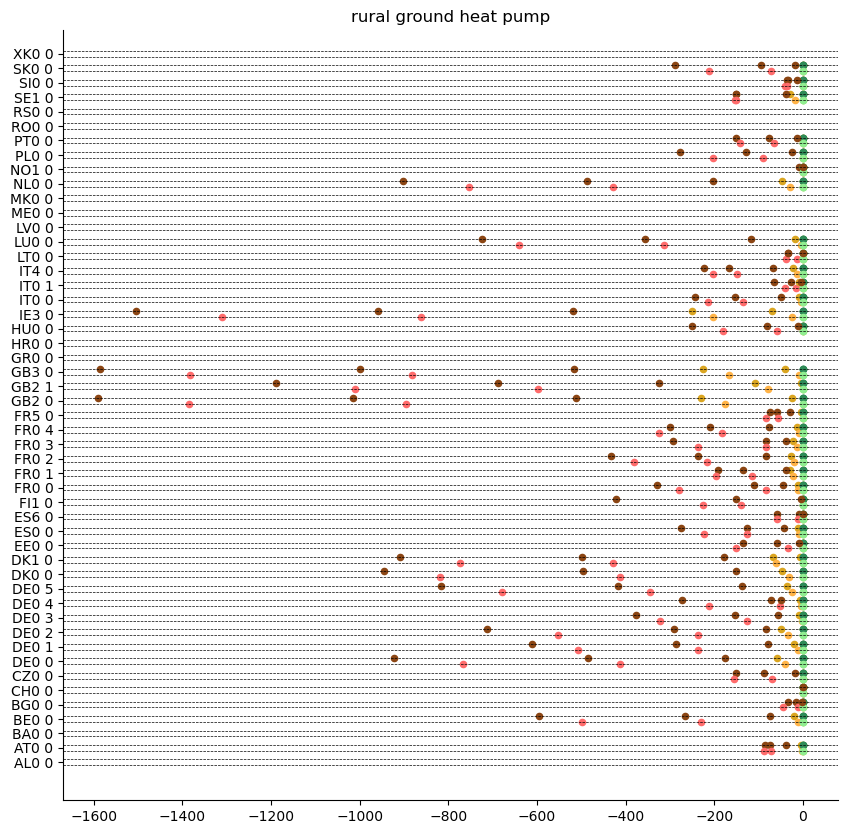

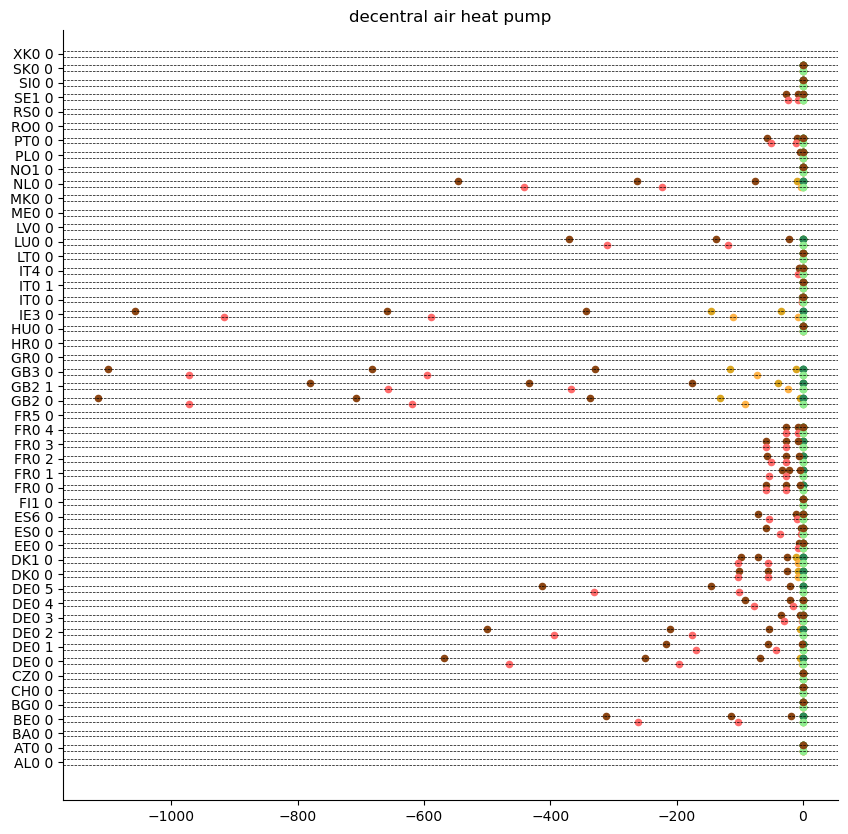

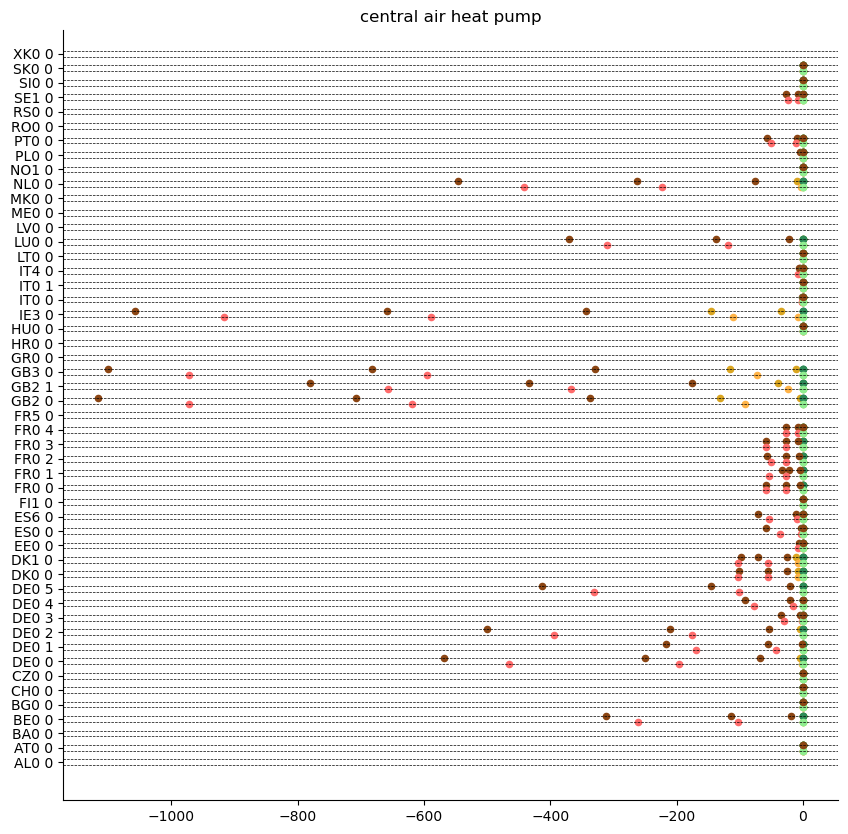

In [ ]:

idx = pd.IndexSlice

for carrier in df.columns.unique(1):

    fig, ax = plt.subplots(figsize=(10, 10))

    # Define discrete color mapping function
    def get_color(wiggle, scenario):
        if wiggle <= 2000:
            return '#8B4513' if scenario == 'medium' else '#FF6B6B'  # Brown/Red for low
        elif wiggle <= 3000:
            return '#DAA520' if scenario == 'medium' else '#FFB347'  # Gold/Orange for mid
        else:
            return '#2E8B57' if scenario == 'medium' else '#90EE90'  # Green/Light green for high

    for i, name in enumerate(df.index):

        ss = df.loc[name, idx[:, carrier, :]].unstack()
        ss.index = ss.index.droplevel(1)
    
        # Color points by wiggle value using discrete colormaps
        for wiggle in ss.columns:
            color_medium = get_color(wiggle, 'medium')
            color_fast = get_color(wiggle, 'fast')
            
            ax.scatter(ss.loc['medium', wiggle], i + 0.2, color=color_medium, s=20)
            ax.scatter(ss.loc['fast', wiggle], i - 0.2, color=color_fast, s=20)

        ax.axhline(i + 0.2, color='k', ls='--', lw=0.5)
        ax.axhline(i - 0.2, color='k', ls='--', lw=0.5)

    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(carrier)

    plt.show()

Index(['offwind', 'onwind', 'solar', 'industrial heat pump high temperature',
       'industrial heat pump medium temperature', 'battery charger',
       'home battery charger'],
      dtype='object')
onwind 2000
offwind 2000
industrial heat pump high temperature 2000
industrial heat pump medium temperature 2000
battery charger 2000
home battery charger 2000


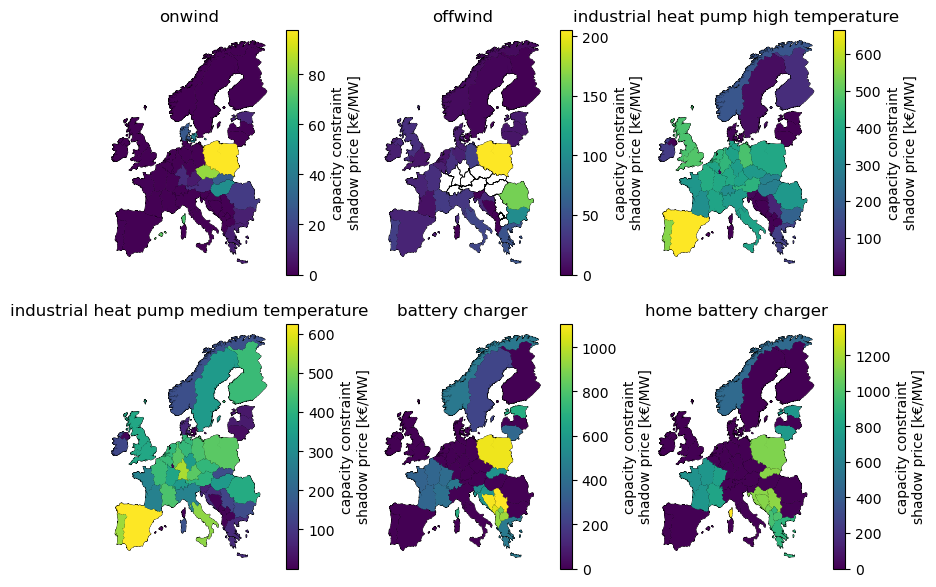

In [46]:
idx = pd.IndexSlice

ss = df.loc[:, idx['fast']]
ss.columns.unique(0)
w = 2000
print(ss.columns.unique(0))

fig, axs = plt.subplots(2, 3, figsize=(10, 7))

regions_plot = regions.copy().to_crs(epsg=4258)

for i, carrier in enumerate([
    'onwind',
    'offwind',
    'industrial heat pump high temperature',
    'industrial heat pump medium temperature',
    # 'decentral air heat pump',
    # 'rural ground heat pump',
    'battery charger',
    'home battery charger',
]):
    
    ax = axs.flatten()[i]

    print(carrier, w)
    regions_plot['col'] = ss.loc[:, idx[carrier, w]].mul(-1)
    # print(ss.loc[:, idx[carrier, w]])
    regions_plot.plot(ax=ax, facecolor='none', lw=0.5)
    regions_plot.plot(ax=ax, column='col', cmap='viridis', legend=True, 
                     legend_kwds={'label': 'capacity constraint\nshadow price [k€/MW]'})

    ax.set_title(carrier)
    ax.set_axis_off()

plt.show()

In [31]:
df

fast                                                         \
          offwind     onwind solar industrial heat pump high temperature   
             2000       2000  2000                                  2000   
name                                                                       
AL0 0    0.000000   0.000000   0.0                             -0.393792   
AT0 0         NaN -12.798678   0.0                           -428.578318   
BA0 0    0.000000   0.000000   0.0                             -0.455947   
BE0 0  -17.483579  -0.000091   0.0                           -386.708368   
BG0 0  -98.911152  -8.482256   0.0                           -207.250162   
CH0 0         NaN   0.000000   0.0                           -324.789043   
CZ0 0         NaN -82.350186   0.0                           -357.846151   
DE0 0  -17.099542   0.000000   0.0                           -381.592574   
DE0 1         NaN   0.000000   0.0                           -365.218887   
DE0 2  -28.184681   0.000000   0.0                           -438.230602   
DE0 3         NaN  -6.838800   0.0                           -382.918339   
DE0 4         NaN -12.109816   0.0                           -399.159381   
DE0 5  -37.351627   0.000000   0.0                           -475.718104   
DK0 0  -15.486914 -27.001783   0.0                             -9.520214   
DK1 0    0.000000 -43.124425   0.0                             -0.321632   
EE0 0  -15.890971 -10.449116   0.0                             -0.963993   
ES0 0  -20.578148   0.000000   0.0                           -666.370891   
ES6 0  -12.316217 -73.824254   0.0                             -0.468353   
FI1 0    0.000000   0.000000   0.0                            -84.289769   
FR0 0  -27.751748   0.000000   0.0                           -410.342914   
FR0 1  -35.529469   0.000000   0.0                           -388.499583   
FR0 2   -8.997387   0.000000   0.0                           -330.306050   
FR0 3  -20.564586  -0.600577   0.0                           -350.985259   
FR0 4         NaN   0.000000   0.0                           -398.756672   
FR5 0  -24.707214 -69.580331   0.0                             -0.172802   
GB2 0  -27.983021   0.000000   0.0                           -475.456458   
GB2 1  -11.985081   0.000000   0.0                           -484.438088   
GB3 0  -23.356440   0.000000   0.0                             -0.640270   
GR0 0  -52.576173  -8.048031   0.0                           -123.982801   
HR0 0  -23.126008   0.000000   0.0                             -0.803293   
HU0 0         NaN -47.988902   0.0                           -285.005003   
IE3 0  -17.078811   0.000000   0.0                           -116.333222   
IT0 0  -42.944211   0.000000   0.0                           -383.160789   
IT0 1  -32.629319   0.000000   0.0                           -359.709120   
IT4 0    0.000000  -0.000104   0.0                             -1.584747   
LT0 0  -11.405360   0.000000   0.0                             -0.714903   
LU0 0         NaN   0.000000   0.0                             -0.283973   
LV0 0  -12.796250   0.000000   0.0                             -0.313297   
ME0 0    0.000000   0.000000   0.0                             -0.269306   
MK0 0         NaN   0.000000   0.0                             -0.375301   
NL0 0  -10.883788   0.000000   0.0                           -431.182218   
NO1 0   -5.830292   0.000000   0.0                           -178.883446   
PL0 0 -205.759878 -97.925826   0.0                           -397.023923   
PT0 0  -37.971955  -0.544465   0.0                           -546.038881   
RO0 0 -162.456949 -16.972166   0.0                           -356.302349   
RS0 0         NaN   0.000000   0.0                            -65.328924   
SE1 0   -3.030711   0.000000   0.0                            -22.499104   
SI0 0    0.000000   0.000000   0.0                            -12.503441   
SK0 0         NaN -28.016360   0.0                           